<h1 style="color:teal;"><strong>Iterative Imputer</strong></h1>

<h2><strong>Iterative Imputer vs KNN Imputer</strong></h2>

While KNN imputer looks at "similar neighbors" , the iterative imputer builds actual mathematical model (like regression or trees) to estimate values. It is generally more robust for complex datasets where the relationships between variables are linear or follow specific pattern. 

(Age, Income, Debt)

1. <strong>Initialization:</strong> Fill all missing values with a placeholder (usually mean, or median of the column).
2. <strong>Target Selection:</strong> Pick one feature (Feature Age) that has missing values. This become y.
3. <strong>Regression Training:</strong> Treat all other features (Income,Debt) as predictors(x). Train a model using only the rows where Feature (Age) is not missing
4. <strong>Prediction: </strong> Use that model to predict missing values in Feature (Age).
5. <strong>Sequential Cycle: </strong>Repeat this for every feature that has missing values.
6. <strong>Iteration: </strong>One full pass through all features is on "Iteration". We repeat the whole cycle multiple times (default 10 ) because the features (Income,Debt) gets updated, it provides a better prediction for Feature (Age) in the next round.

In [1]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

In [2]:
np.random.seed(42)
age = np.random.randint(20,60,100)
income = (age * 2000) + np.random.normal(0,5000,100)
df = pd.DataFrame({'Age':age,'Income':income})

In [4]:
df.iloc[1:10,0] = np.nan
df.iloc[50:60,1] = np.nan
df

,Age,Income
0,58.0,115111.339394
1,NaN,93948.083457
2,NaN,73898.581724
3,NaN,49508.960303
4,NaN,84173.977096
...,...,...
95,28.0,61953.636281
96,27.0,60496.984071
97,31.0,57664.269220
98,53.0,109088.204228


In [7]:
df.isnull().sum()/len(df)*100

Age        9.0
Income    10.0
dtype: float64

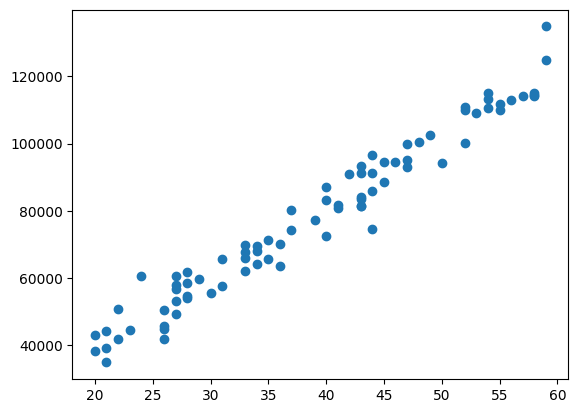

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['Age'],df['Income'])
plt.show()

In [10]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)

In [11]:
df_scaled

,Age,Income
0,1.641162,1.547841
1,NaN,0.659227
2,NaN,-0.182623
3,NaN,-1.206708
4,NaN,0.248826
...,...,...
95,-0.924916,-0.684174
96,-1.010452,-0.745337
97,-0.668308,-0.864278
98,1.213482,1.294939


In [12]:
it_imputer = IterativeImputer(max_iter=10,random_state=42)
df_imputed_scaled = it_imputer.fit_transform(df_scaled)

In [15]:
df_final = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled),columns=df.columns)

df_final.head(20)

,Age,Income
0,58.000000,115111.339394
1,46.009204,93948.083457
2,36.792443,73898.581724
3,25.580528,49508.960303
4,41.516045,84173.977096
5,56.828123,117482.806922
6,35.373012,70810.850617
7,41.261833,83620.981275
8,32.639619,64864.817669
9,32.231939,63977.977319


In [14]:
df_final.isnull().sum()

Age       0
Income    0
dtype: int64